In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn
import kind

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco/hopper'
result_path = '../../../results/mujoco'

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', data_path,
        '--file_name', 'hopper',
        '--data_nsample_baseline', '9850',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--data_train_size', '0.8',
        '--obs_ndim', '11',
        '--act_ndim', '3',
        '--target_ndim', '11',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', model_path,

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 10, "cos": 10}',
        '--embed_exc', '{"data": 20}',
    ]
)

# --! instantiate a KIND model
model = kind.model(args)

# --! load trained weights into the model
model_path = args.checkpoints + '/' + '20260314_kind_checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

setpoint = torch.zeros(args.target_ndim)

dataset = example_mujoco.dataset(args, setpoint, load_normalized=False, extract_windows=True)
model = kind.model_adapter(model, dataset.normalizer)

shape of read Hopper trajectory: torch.Size([1, 9850, 14])


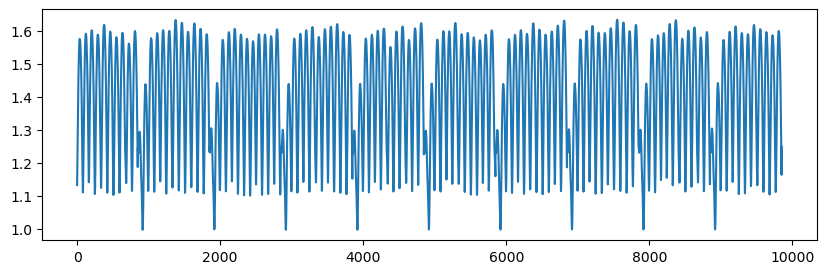

In [3]:
skip_nsample = 150
traj_nsample = 10_000 - skip_nsample
traj_true = util_data.read_datafile(f'{data_path}/hopper_baseline_0', traj_nsample)
print(f'shape of read Hopper trajectory: {traj_true.shape}')

plt.figure(figsize=(10,3))
plt.plot(traj_true[0, :, 0])
plt.show()


In [7]:
# --! perform model rollout --!

offset = 1_000
h = 800 # rollout length, horizon
reset_nsample = 1_000 # re-anchor after this number of samples

true, next_ss, alphas, zetas_nom, zetas_exc, means_nom, means_exc = example_mujoco.rollout_kind(
    model,
    traj_true,
    horizon=h, reset_nsample=reset_nsample, offset=offset)

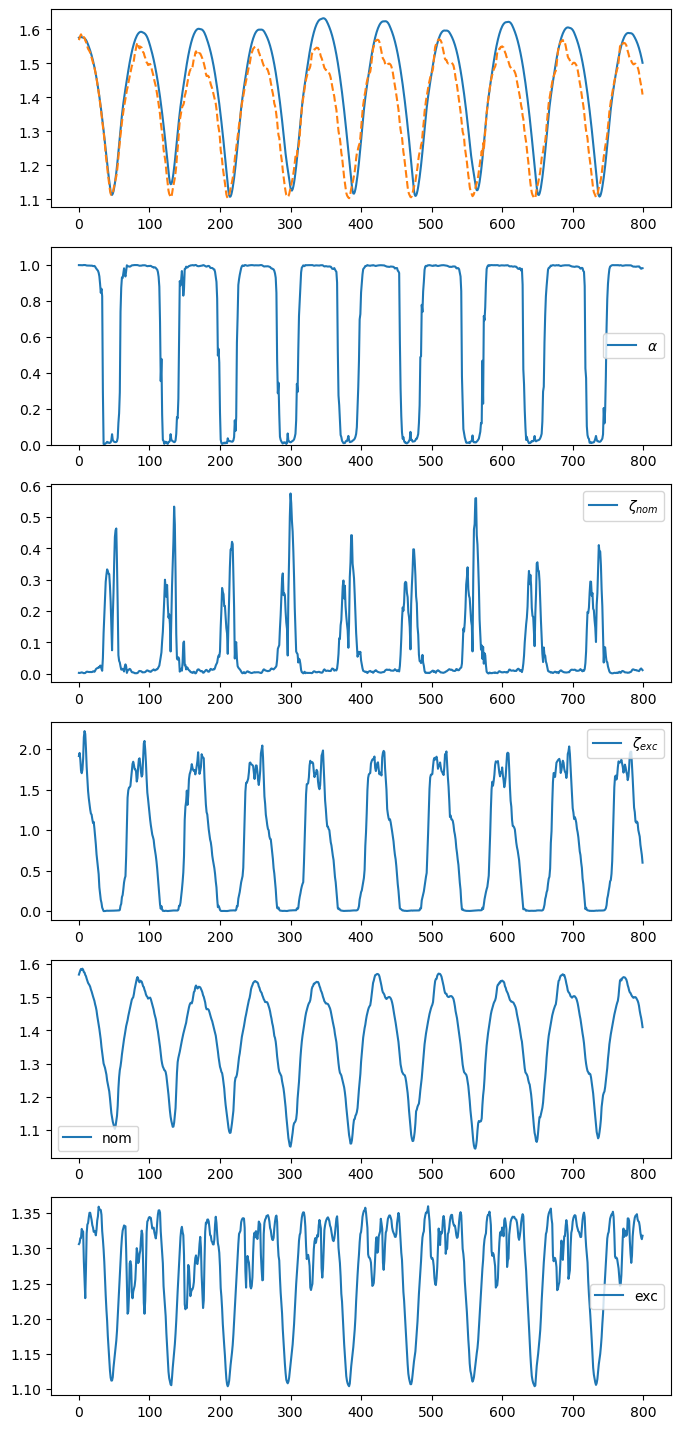

In [8]:

with torch.no_grad():
    plt.figure(figsize=(8,18))

    plt.subplot(6,1,1)
    plt.plot(true[0, :, 0])
    plt.plot(next_ss[0, :, 0], linestyle='dashed')

    plt.subplot(6,1,2)
    plt.plot(alphas[0, :, 0], label='$\\alpha$')
    plt.ylim((0.0, 1.1))
    plt.legend()

    plt.subplot(6,1,3)
    plt.plot(zetas_nom[0, :, 0], label='$\\zeta_{nom}$')
    plt.legend()

    plt.subplot(6,1,4)
    plt.plot(zetas_exc[0, :, 0], label='$\\zeta_{exc}$')
    plt.legend()

    plt.subplot(6,1,5)
    plt.plot(means_nom[0, :, 0], label='nom')
    plt.legend()

    plt.subplot(6,1,6)
    plt.plot(means_exc[0, :, 0], label='exc')
    plt.legend()

    plt.show()

## Save rollout data

In [ ]:
datasaved = False

if datasaved:
    step = torch.arange(true.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        step,
        true[..., :1], next_ss[..., :1], alphas[..., :1], zetas_nom[..., :1]], axis=2)
    util_data.write_datafile(f'../../results/mujoco/hopper_kind_rollout_reanchor_250', savedata, delim=' ')